In [2]:
import pandas as pd
import numpy as np
from Preprocessing import CombinedPreprocessor
from RandomCV import RandomCV
from GroupKFoldCV import GroupKFoldCV
from SpatialPlusCV import SpatialPlusCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from IPython.display import display

/opt/anaconda3/envs/REU3.9.6/lib/python3.9/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/REU3.9.6/lib/python3.9/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/REU3.9.6/lib/python3.9/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/REU3.9.6/lib/python3.9/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was exp

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.144977,0.539791,0.003391,0.020246
1,LR,TEST,0.255023,-0.415354,0.009140,0.102983
2,RF,CV,0.089465,0.824632,0.002430,0.010718
3,RF,TEST,0.279579,-0.713036,0.025530,0.301651
4,XGB,CV,0.095147,0.801422,0.004236,0.017975
5,XGB,TEST,0.271757,-0.613197,0.019262,0.234769


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.205882,-0.977847,0.042814,1.615668
1,LR,TEST,0.355162,-1.912498,0.088674,1.402471
2,RF,CV,0.169197,-0.512624,0.071061,1.382849
3,RF,TEST,0.232733,-0.220314,0.044514,0.444304
4,XGB,CV,0.173855,-0.505981,0.069688,1.244963
5,XGB,TEST,0.241489,-0.316466,0.047469,0.489851


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.178518,0.106728,0.033566,0.313137
1,LR,TEST,0.322294,-1.385703,0.076759,1.115798
2,RF,CV,0.140733,0.391330,0.050304,0.376015
3,RF,TEST,0.255940,-0.463624,0.042846,0.445156
4,XGB,CV,0.143239,0.361157,0.049608,0.395490
5,XGB,TEST,0.258442,-0.485007,0.039148,0.411801


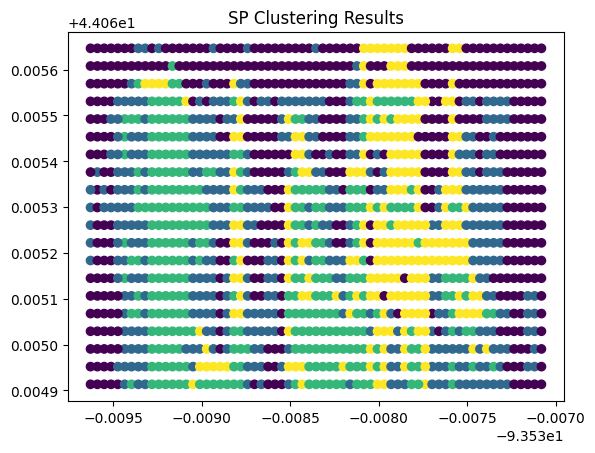

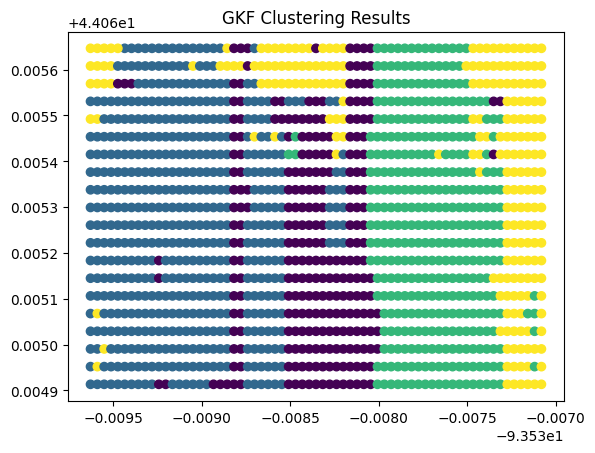

In [3]:
p = CombinedPreprocessor()

indices_6182020 = pd.read_csv("../../Datasets/Indices_Combined/2020/June_18_2020_New.csv")
indices_6232020 = pd.read_csv("../../Datasets/Indices_Combined/2020/June_23_2020_New.csv")
indices_6302020 = pd.read_csv("../../Datasets/Indices_Combined/2020/June_30_2020_New.csv")
indices_7062020 = pd.read_csv("../../Datasets/Indices_Combined/2020/July_6_2020_New.csv")
clusters_2020 = pd.read_csv("../../Datasets/Clusters/combined_2020_clustering.csv")['CLUSTER_ID'].to_numpy()

X_train_validate, X_test, Y_train_validate, Y_test = p.transform([indices_6182020, indices_6232020, indices_6302020], indices_7062020)

random_validator = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, clusters=clusters_2020)
sp_validator = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results = random_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
gkf_results = gkf_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
sp_results = sp_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)

display(random_results, gkf_results, sp_results)
sp_validator.display_clusters()
gkf_validator.display_clusters()


,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.119996,0.514741,0.004285,0.021694
1,LR,TEST,0.347750,-3.317941,0.092571,2.197507
2,RF,CV,0.092717,0.710276,0.004129,0.017288
3,RF,TEST,0.134348,0.394354,0.010699,0.097131
4,XGB,CV,0.094398,0.699594,0.006254,0.027929
5,XGB,TEST,0.143913,0.303231,0.013634,0.134880


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.176558,-0.386583,0.046720,0.813714
1,LR,TEST,0.372379,-3.873341,0.086545,2.260745
2,RF,CV,0.134206,0.244381,0.017989,0.239474
3,RF,TEST,0.148788,0.234250,0.028771,0.309305
4,XGB,CV,0.143737,0.141437,0.031394,0.330218
5,XGB,TEST,0.139197,0.351178,0.009117,0.087067


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.160657,0.044750,0.043786,0.476556
1,LR,TEST,0.426403,-5.477591,0.111578,3.317903
2,RF,CV,0.110866,0.560187,0.014717,0.152239
3,RF,TEST,0.141698,0.319719,0.017999,0.172310
4,XGB,CV,0.117443,0.501971,0.017855,0.196683
5,XGB,TEST,0.160279,0.110401,0.031475,0.343538


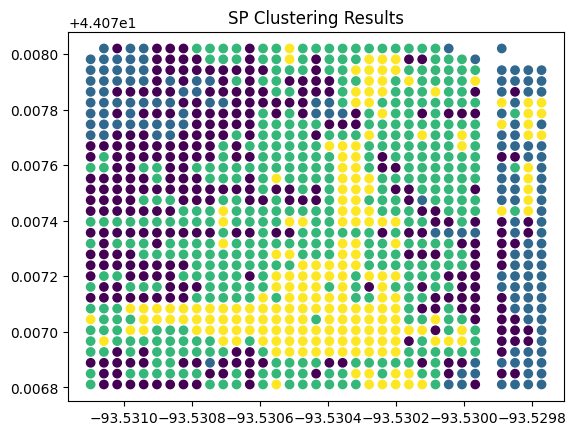

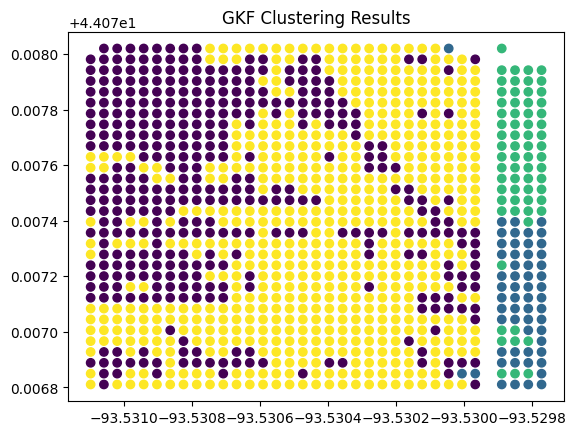

In [3]:
p1 = CombinedPreprocessor()

indices_6162021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_16_2021.csv")
indices_6222021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_22_2021.csv")
indices_6302021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_30_2021.csv")
indices_7122021 = pd.read_csv("../Datasets/Indices_Combined/2021/July_12_2021.csv")
clusters_2021 = pd.read_csv("../Datasets/Clusters/combined_2021_clustering.csv")['CLUSTER_ID'].to_numpy()

X_train_validate1, X_test1, Y_train_validate1, Y_test1 = p1.transform([indices_6162021, indices_6222021, indices_6302021], indices_7122021)

random_validator1 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator1 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, clusters=clusters_2021)
sp_validator1 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results1 = random_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
gkf_results1 = gkf_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
sp_results1 = sp_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)

display(random_results1, gkf_results1, sp_results1)
sp_validator1.display_clusters()
gkf_validator1.display_clusters()

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.132576,0.272773,0.017861,0.185096
1,LR,TEST,0.389108,-5.859861,0.070541,2.377965
2,RF,CV,0.103424,0.568556,0.015363,0.052286
3,RF,TEST,0.137350,0.171430,0.004836,0.059031
4,XGB,CV,0.107159,0.532520,0.013714,0.071391
5,XGB,TEST,0.137972,0.158900,0.011743,0.142758


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.162728,-1.128513,0.051976,1.177092
1,LR,TEST,0.355902,-4.930435,0.092340,2.837868
2,RF,CV,0.156500,-0.656414,0.053636,0.484498
3,RF,TEST,0.152594,-0.033753,0.016765,0.234977
4,XGB,CV,0.177793,-1.192951,0.070464,0.914079
5,XGB,TEST,0.152806,-0.039760,0.018792,0.260247


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.162689,-0.357874,0.078205,0.604822
1,LR,TEST,0.423245,-7.126694,0.078252,3.004260
2,RF,CV,0.126418,0.153500,0.036856,0.218045
3,RF,TEST,0.143738,0.092373,0.005478,0.069346
4,XGB,CV,0.128581,0.142513,0.040221,0.192778
5,XGB,TEST,0.137924,0.164185,0.005529,0.066897


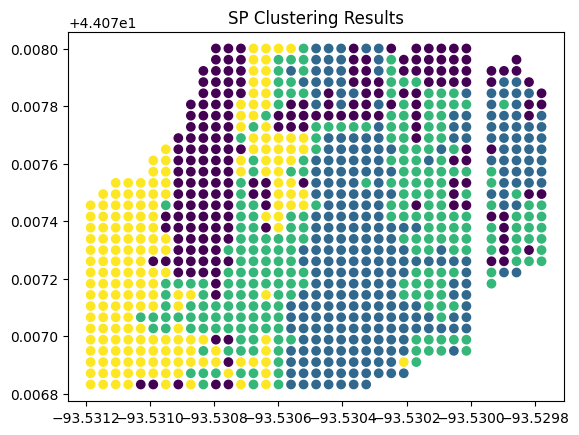

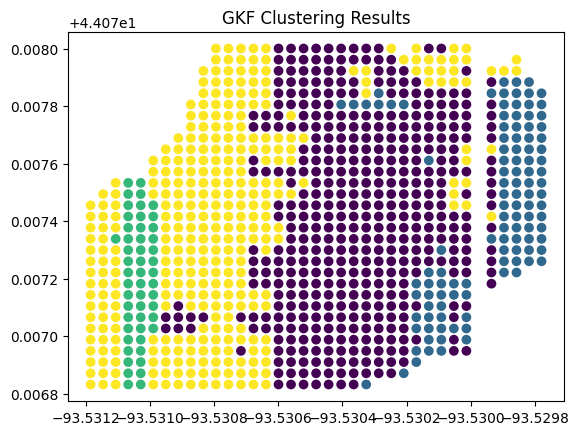

In [4]:
p2 = CombinedPreprocessor()

indices_6152022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_15_2022.csv")
indices_6232022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_23_2022.csv")
indices_6282022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_28_2022.csv")
indices_7132022 = pd.read_csv("../Datasets/Indices_Combined/2022/July_13_2022.csv")
clusters_2022 = pd.read_csv("../Datasets/Clusters/combined_2022_clustering.csv")['CLUSTER_ID'].to_numpy()

X_train_validate2, X_test2, Y_train_validate2, Y_test2 = p2.transform([indices_6152022, indices_6232022, indices_6282022], indices_7132022)

random_validator2 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator2 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, clusters=clusters_2022)
sp_validator2 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results2 = random_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
gkf_results2 = gkf_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
sp_results2 = sp_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)

display(random_results2, gkf_results2, sp_results2)
sp_validator2.display_clusters()
gkf_validator2.display_clusters()